## Manual Round 2

Every player in the set of players N = {1,2,3 ...} has the same utiil function:

$$U_i = 200000 \cdot \frac{log(1+r)}{log(1+100)} \cdot 0.07 \cdot (s_1) \cdot m(s_2) - X$$

Where:
- X = Budget Spend 
- r = % of budget spent on Research
- s1 = % of budget spent on Scale
- s2 = % of budget spent on Speed

The tricky part is that the first two two parts of the utility function are deterministic, for these we should be able to calculate an optimal combination of r and s1. We also need to account for that not all 50,000 needs to be spend, we need to use partial deriavtives or someting to determine when adding X to research or scale has a marginal utitility that is equal to the spend.

However how should we account for the m function? Whether adding X into the log function or the linear factor depends entirely on what the multiplier is. 

Since we know the multiplier is a constant between [0,1 -> 0.9] we can actually use these constants and compute when adding X is better in the different scenarios. Suppose our m function is a constant M.

$$U_i = 200000 \cdot \frac{\log(1+r)}{\log(101)} \cdot 0.07(s_1) \cdot M - X$$

Now what distribution of X maximises M? Both $r$ and $s_1$ are selected paramaters based on how to allocate the share across the different departments. $X$ is the total spend. Our utility looks something like this: 

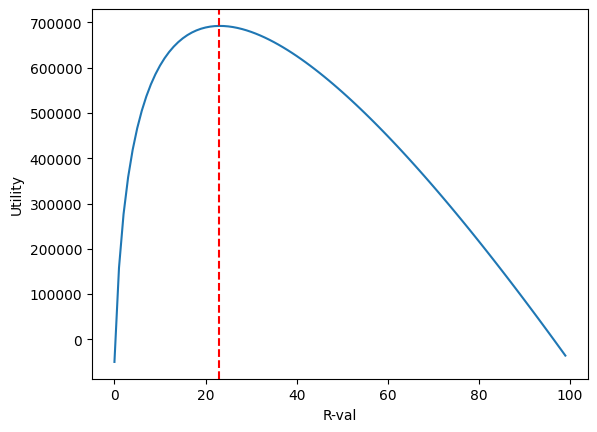

Best R-val: 23
Best S1-val: 77


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



X = 50000

r = []
s1 = []

for i in range(0, 100):
    r.append(i)
    s1.append(100-i)

r = pd.Series(r)
s1 = pd.Series(s1)

df = pd.concat([r, s1], axis=1, keys=['r', 's1'])

for i in df.index:
    df.loc[i, 'utility'] = 200000 * np.log(1 + df.loc[i, 'r']) / np.log(101) * 0.07 * df.loc[i, 's1']  - X

fig, ax = plt.subplots()

ax.plot(df["r"], df["utility"])
ax.set_xlabel("R-val")
ax.set_ylabel("Utility")

optimal_u = max(df["utility"])
optimal_r = df[df["utility"] == optimal_u]["r"].item()

ax.axvline(optimal_r, color="red", linestyle="--")

plt.show()
print(f"Best R-val: {optimal_r}")
print(f"Best S1-val: {100-optimal_r}")

But we should not assume that the solution is optimal for spending the whole 50K instead we need a solver. Now instead of trying to prove this with 10 pages of calc, lets just numerically optimize this function:

$$U = \frac{200000}{\log(101)} \cdot \log(1+\frac{100x}{50000}) \cdot 0.07(\frac{100s1}{50000}) - X$$


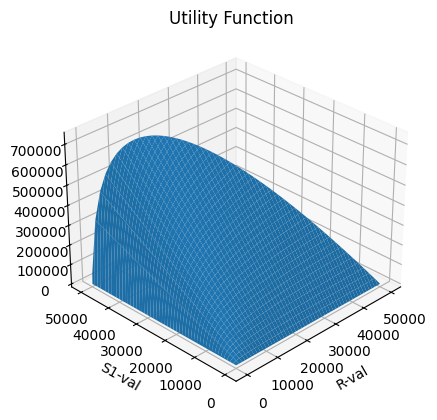

Optimal R: 11600
Optimal S: 38400
Optimal U: 742335.0


In [18]:
BUDGET = 50000

r_vals = np.arange(0, BUDGET, 100)
s_vals = np.arange(0, BUDGET, 100)

R, S = np.meshgrid(r_vals, s_vals)
mask = (R + S) <= BUDGET

U = np.full(R.shape, np.nan)
U[mask] = 200000/np.log(101) * np.log(1 + (100*R[mask])/BUDGET) * 0.07*((100 * S[mask])/BUDGET)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(R, S, U)
ax.view_init(elev=30, azim=225)
ax.set_title("Utility Function")
ax.set_xlabel("R-val")
ax.set_ylabel("S1-val")

plt.show()

idx = np.nanargmax(U)
U_max = round(U.flat[idx], 0)
i, j = np.unravel_index(idx, U.shape)
R_opt, S_opt = R[i, j], S[i, j]

print(f"Optimal R: {R_opt}")
print(f"Optimal S: {S_opt}")
print(f"Optimal U: {U_max}")

Now to find the optimal overall solution we need to compute expected multipliers given certain inputs. Now Everyone has the base strategy S1 which is essentially the above, aka place nothing towards speed and pocket 692,335 * 0.1 = 69.2 K risk free. Adjusting for risk this is the optimal play because it is essentially free money. Since this is only the qualifying round there is 0 point showboating with high PnLs the only thing needed is to pass to the finals. 

From the leaderboard data circa 4,000 serious teams actually participating seem to be in the contest. Of these circa 2,000 teams are more or less guaranteed to go on to round 2. We'd assume that these teams are the ones doing the same math as we are doing above. The rest of the 2k teams have garbage PnL and will likely just use vibes/random to select their manual trades. 

Let's for the sake of thinking about it, assume that 0-50K input S2 will scale the multiplier linearly. Then at what split do we find the optimal? 


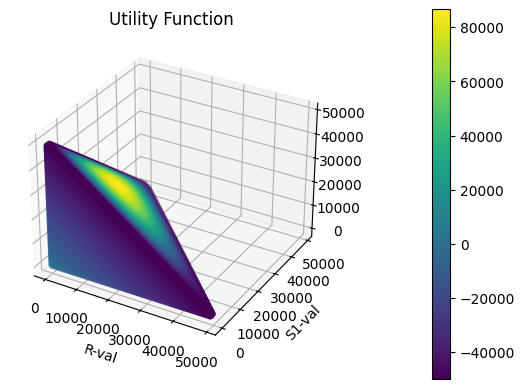

Optimal R: 7000
Optimal S: 21000
Optimal M: 22000
Optimal U: 86630.0


In [9]:
BUDGET = 50000

r_vals = np.arange(0, BUDGET, 1000)
s_vals = np.arange(0, BUDGET, 1000)
t_vals = np.arange(0, BUDGET, 1000)

R, S, T = np.meshgrid(r_vals, s_vals, t_vals)
mask = (R + S + T) <= BUDGET

U = np.full(R.shape, np.nan)
U[mask] = 200000/np.log(101) * np.log(1 + (100*R[mask])/BUDGET) * 0.07*((100 * S[mask])/BUDGET) * (0.9 * (T[mask]/50000))  - (R[mask] + S[mask] + T[mask]) 

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(R, S, T, c=U, cmap='viridis')
plt.colorbar(sc, ax=ax, pad=0.2)
ax.set_title("Utility Function")
ax.set_xlabel("R-val")
ax.set_ylabel("S1-val")
plt.show()

idx = np.nanargmax(U)
U_max = round(U.flat[idx], 0)
i, j, k = np.unravel_index(idx, U.shape)
R_opt, S_opt, T_opt = R[i, j, k], S[i, j, k], T[i, j, k]

print(f"Optimal R: {R_opt}")
print(f"Optimal S: {S_opt}")
print(f"Optimal M: {T_opt}")
print(f"Optimal U: {U_max}")


In [27]:
R = 10600
S = 38400
M = 0.1

U = 200000 * np.log(1 + (100*R/50000)) / np.log(101) * 0.07 * (100*S/50000) * M - 50000
print(round(U, 0))

print(10600/50000)
print(38400/50000)
print(1000/50000)

22224.0
0.212
0.768
0.02
